# Problem 3 Exam

Zeynep Aslan - 19352741

Natasha Machate - 17752915

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [27]:
DPI = 110
METHOD_PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D014FF", "#CC79A7", "#56B4E9"]
FACILITY_SHORT = {
    "Transiting Exoplanet Survey Satellite (TESS)": "TESS",
    "La Silla Observatory": "La Silla",
    "W. M. Keck Observatory": "W. M. Keck"
}
PARAMETERS = [
    "pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_dens",
    "pl_eqt", "st_teff", "st_rad", "st_mass", "sy_dist"
]
PARAMETER_LABELS = {
    "pl_orbper": "Orbital period (days)",
    "pl_orbsmax": "Orbit semi-major axis (AU)",
    "pl_rade": "Planet radius (Earth radii)",
    "pl_bmasse": "Planet mass (Earth masses)",
    "pl_dens": "Planet density (g/cm³)",
    "pl_eqt": "Equilibrium temperature (K)",
    "st_teff": "Stellar effective temperature (K)",
    "st_rad": "Stellar radius (Solar radii)",
    "st_mass": "Stellar mass (Solar masses)",
    "sy_dist": "System distance (pc)"
}
GROUP_COLORS = {"Planet": "#6F63B6", "Star": "#D28E45", "System": "#3A9D8F"}
AX_TITLE_KW = {"loc": "center", "fontsize": 15, "fontweight": "bold", "pad": 13}
PANEL_TITLE_KW = {"fontsize": 12, "fontweight": "normal", "pad": 12}
SUPTITLE_KW = {"fontsize": 15, "fontweight": "bold"}

sns.set_theme(style="whitegrid", context="notebook")

## 1. Import the data

In [28]:
df = pd.read_csv("./exoplanets.csv", sep=";", encoding="utf-8")

METHOD_MIN_SHARE = 1.0

method_counts = df["discoverymethod"].value_counts()
method_share = method_counts.div(method_counts.sum()).mul(100)
METHODS = method_share[method_share >= METHOD_MIN_SHARE].index.tolist()
METHODS = sorted(METHODS, key=method_counts.get, reverse=True)

FACILITIES = [
    "Kepler",
    "Transiting Exoplanet Survey Satellite (TESS)",
    "La Silla Observatory",
    "W. M. Keck Observatory",
    "OGLE",
    "K2",
    "KMTNet",
    "Multiple Observatories"
]
METHOD_COLORS = {method: METHOD_PALETTE[i % len(METHOD_PALETTE)] for i, method in enumerate(METHODS)}
FACILITY_COLORS = {
    "Kepler": "#4477AA",
    "Transiting Exoplanet Survey Satellite (TESS)": "#EE7733",
    "La Silla Observatory": "#33BBEE",
    "W. M. Keck Observatory": "#CC6677",
    "OGLE": "#CCBB44",
    "K2": "#AA3377",
    "KMTNet": "#228833",
    "Multiple Observatories": "#888888"
}
FACILITY_LABELS = {facility: FACILITY_SHORT.get(facility, facility) for facility in FACILITIES}
FACILITY_LABEL_COLORS = {FACILITY_LABELS[facility]: FACILITY_COLORS[facility] for facility in FACILITIES}


## 2. Discovery methods, facilities, and timeline

### 2.1 Timeline of discovery by method 

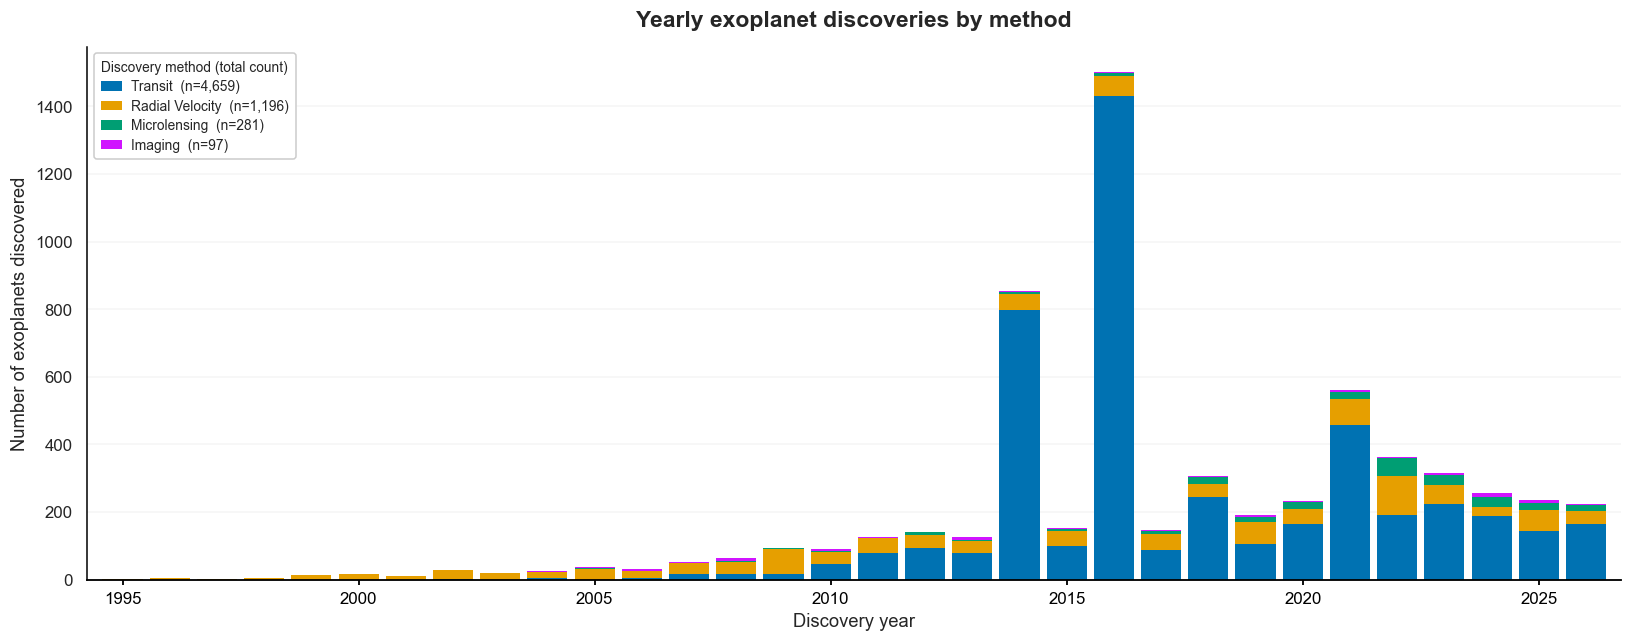

In [29]:
timeline_data = df.dropna(subset=["disc_year", "discoverymethod"]).copy()
timeline_data["disc_year"] = timeline_data["disc_year"].astype(int)
timeline_data = timeline_data[timeline_data["discoverymethod"].isin(METHODS)]
year_method = pd.crosstab(timeline_data["disc_year"], timeline_data["discoverymethod"]).reindex(columns=METHODS, fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(15, 6), dpi=DPI)
bottom = np.zeros(len(year_method))
for method in METHODS:
    ax.bar(year_method.index, year_method[method], bottom=bottom, width=0.85, color=METHOD_COLORS[method], edgecolor="none", linewidth=0, label=f"{method}  (n={method_counts[method]:,})")
    bottom += year_method[method].to_numpy()

first_year, last_year = year_method.index.min(), year_method.index.max()
year_ticks = np.arange(int(np.ceil(first_year / 5) * 5), int(np.floor(last_year / 5) * 5) + 1, 5)
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_ticks)
ax.set_xlim(first_year - 0.75, last_year + 0.75)
ax.tick_params(axis="x", bottom=True, top=False, direction="out", length=3, width=1.2, color="black", labelcolor="black", pad=5)
ax.set_title("Yearly exoplanet discoveries by method", **AX_TITLE_KW)
ax.set_xlabel("Discovery year")
ax.set_ylabel("Number of exoplanets discovered")
ax.legend(title="Discovery method (total count)", loc="upper left", frameon=True, facecolor="white", edgecolor="#CCCCCC", framealpha=1, fontsize=9, title_fontsize=9, alignment="left", borderpad=0.5, labelspacing=0.4, handlelength=1.5, handletextpad=0.7)
ax.grid(axis="y", alpha=0.20)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
sns.despine(fig=fig)
ax.spines["bottom"].set(color="black", linewidth=1.2)
ax.spines["left"].set(color="black", linewidth=1.0)
fig.tight_layout()
plt.show()


### 2.2 Timeline of discovery by facility

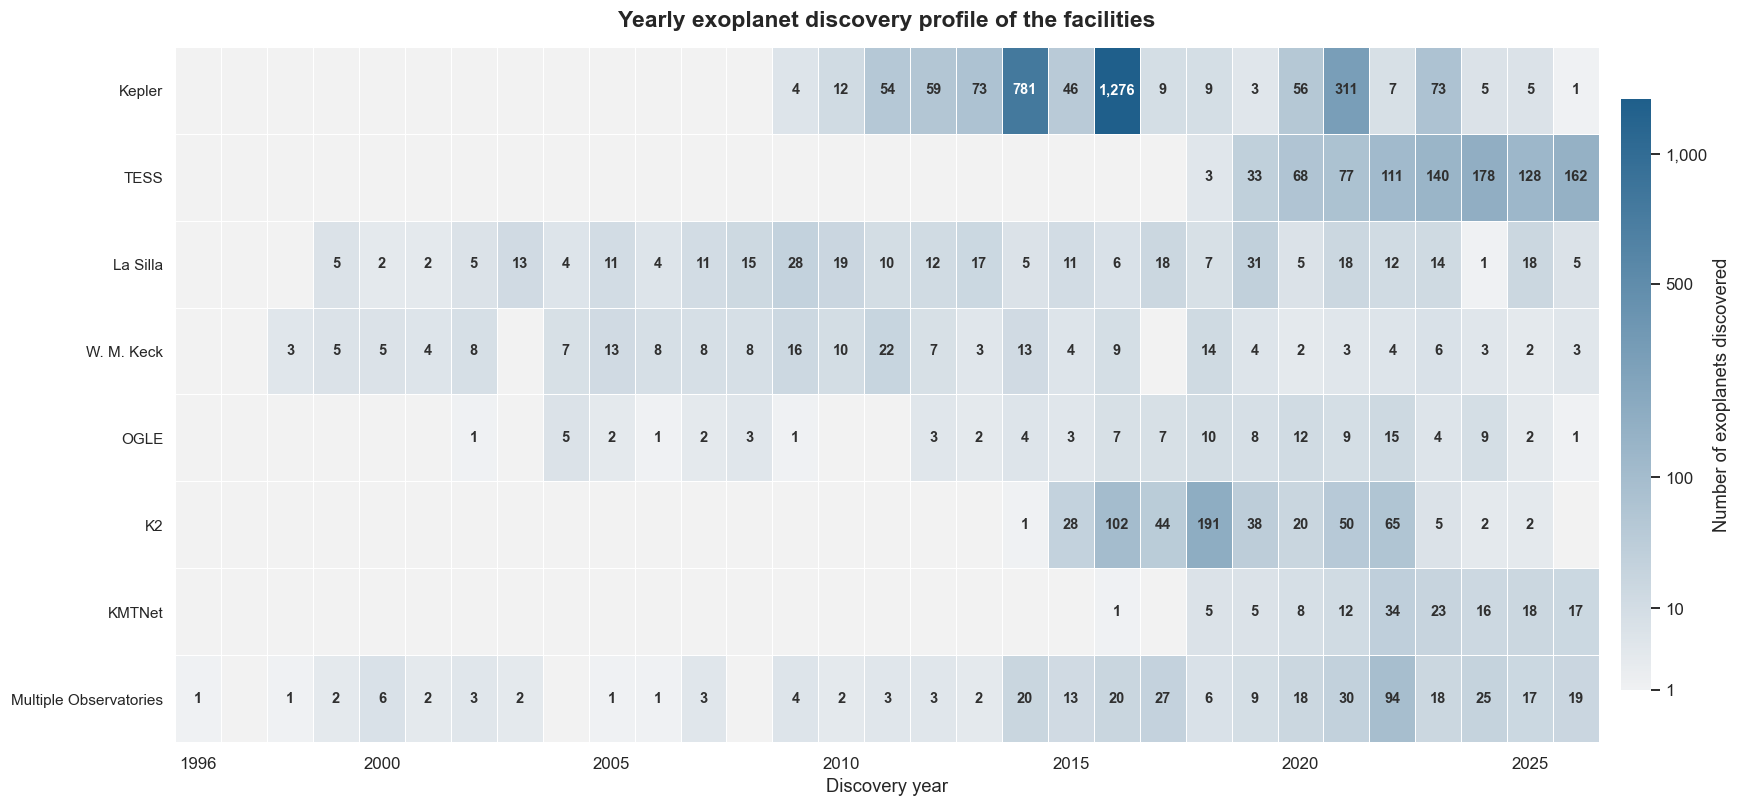

In [30]:
facility_timeline_data = df.loc[df["disc_facility"].isin(FACILITIES), ["disc_facility", "disc_year"]].dropna().copy()
facility_timeline_data["disc_year"] = facility_timeline_data["disc_year"].astype(int)
year_facility = pd.crosstab(facility_timeline_data["disc_facility"], facility_timeline_data["disc_year"]).reindex(index=FACILITIES, fill_value=0)
first_year, last_year = facility_timeline_data["disc_year"].min(), facility_timeline_data["disc_year"].max()
full_years = np.arange(first_year, last_year + 1)
year_facility = year_facility.reindex(columns=full_years, fill_value=0).rename(index=FACILITY_SHORT)
values = year_facility.to_numpy()
n_rows, n_cols, vmax = values.shape[0], values.shape[1], values.max()
masked_values = np.ma.masked_where(values == 0, values)
cmap = sns.light_palette("#1F5F8B", n_colors=256, as_cmap=True).copy()
cmap.set_bad("#F2F2F2")
color_norm = PowerNorm(gamma=0.40, vmin=1, vmax=vmax)

fig, ax = plt.subplots(figsize=(16, 7.5), dpi=DPI)
mesh = ax.pcolormesh(np.arange(n_cols + 1), np.arange(n_rows + 1), masked_values, cmap=cmap, norm=color_norm, edgecolors="white", linewidth=0.5)
for row in range(n_rows):
    for column in range(n_cols):
        value = values[row, column]
        if value > 0:
            ax.text(column + 0.5, row + 0.5, f"{value:,}", ha="center", va="center", fontsize=9.5, fontweight="bold", color="white" if color_norm(value) > 0.58 else "#303030")

ax.invert_yaxis()
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(year_facility.index, fontsize=10)
tick_years = np.r_[first_year, np.arange(((first_year // 5) + 1) * 5, last_year + 1, 5)].astype(int)
tick_positions = np.searchsorted(full_years, tick_years) + 0.5
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_years, rotation=0)
ax.tick_params(axis="y", length=0, pad=8)
ax.set_xlabel("Discovery year")
ax.set_ylabel("")
ax.set_title("Yearly exoplanet discovery profile of the facilities", **AX_TITLE_KW)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(mesh, ax=ax, fraction=0.02, pad=0.015)
colorbar.set_label("Number of exoplanets discovered")
colorbar_ticks = [value for value in [1, 10, 100, 500, 1000, 2000] if value <= vmax]
colorbar.set_ticks(colorbar_ticks)
colorbar.set_ticklabels([f"{value:,}" for value in colorbar_ticks])
colorbar.ax.minorticks_off()
colorbar.ax.tick_params(which="minor", length=0)
colorbar.outline.set_visible(False)
fig.tight_layout()
plt.show()

### 2.3 Which facilities use which methods

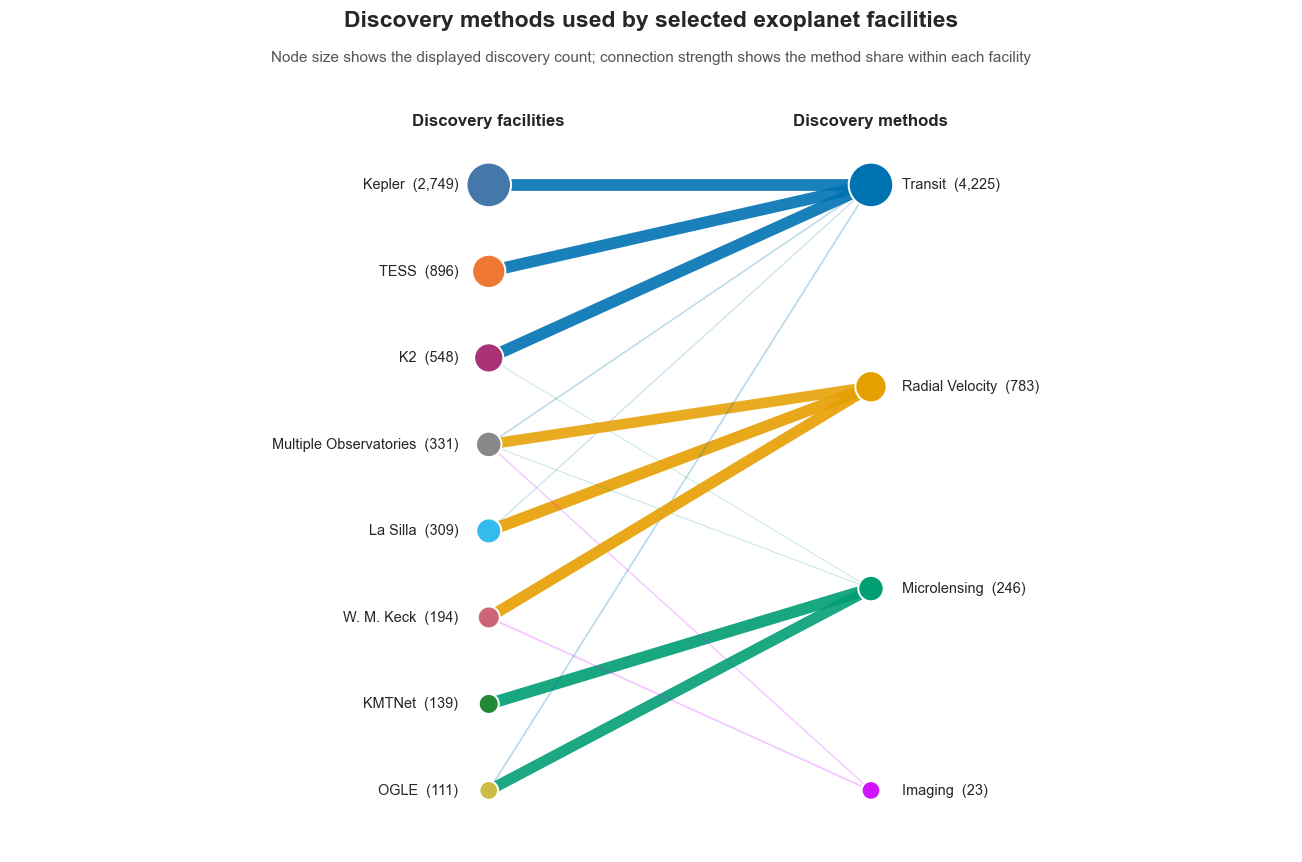

In [31]:
network_data = df.loc[df["disc_facility"].isin(FACILITIES) & df["discoverymethod"].isin(METHODS), ["disc_facility", "discoverymethod"]].dropna().copy()
edge_counts = network_data.groupby(["disc_facility", "discoverymethod"]).size()
edge_counts = edge_counts[edge_counts > 0]
facility_totals = network_data["disc_facility"].value_counts()
method_totals = network_data["discoverymethod"].value_counts()
facilities_sorted = sorted([facility for facility in FACILITIES if facility_totals.get(facility, 0) > 0], key=lambda facility: facility_totals[facility], reverse=True)
methods_sorted = sorted([method for method in METHODS if method_totals.get(method, 0) > 0], key=lambda method: method_totals[method], reverse=True)
plot_height = max(len(facilities_sorted) - 1, len(methods_sorted) - 1)
positions = {facility: (0, y) for facility, y in zip(facilities_sorted, np.linspace(0, -plot_height, len(facilities_sorted)))}
positions.update({method: (1, y) for method, y in zip(methods_sorted, np.linspace(0, -plot_height, len(methods_sorted)))})

fig, ax = plt.subplots(figsize=(12, 8.5), dpi=DPI)
for (facility, method), count in edge_counts.items():
    if facility not in positions or method not in positions:
        continue
    x0, y0 = positions[facility]
    x1, y1 = positions[method]
    share = count / facility_totals[facility]
    ax.plot([x0, x1], [y0, y1], color=METHOD_COLORS[method], linewidth=0.7 + 7 * share, alpha=min(0.20 + 0.75 * share, 0.90), solid_capstyle="round", zorder=1)

facility_values = np.sqrt(facility_totals.reindex(facilities_sorted).to_numpy())
method_values = np.sqrt(method_totals.reindex(methods_sorted).to_numpy())
facility_sizes = 150 + (facility_values - facility_values.min()) / max(facility_values.max() - facility_values.min(), 1) * 700
method_sizes = 150 + (method_values - method_values.min()) / max(method_values.max() - method_values.min(), 1) * 700
ax.scatter([0] * len(facilities_sorted), [positions[facility][1] for facility in facilities_sorted], s=facility_sizes, color=[FACILITY_COLORS[facility] for facility in facilities_sorted], edgecolor="white", linewidth=1.3, zorder=3)
ax.scatter([1] * len(methods_sorted), [positions[method][1] for method in methods_sorted], s=method_sizes, color=[METHOD_COLORS[method] for method in methods_sorted], edgecolor="white", linewidth=1.3, zorder=3)
for facility in facilities_sorted:
    ax.text(-0.08, positions[facility][1], f"{FACILITY_LABELS[facility]}  ({facility_totals[facility]:,})", ha="right", va="center", fontsize=9.5)
for method in methods_sorted:
    ax.text(1.08, positions[method][1], f"{method}  ({method_totals[method]:,})", ha="left", va="center", fontsize=9.5)
ax.text(0, 0.65, "Discovery facilities", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.text(1, 0.65, "Discovery methods", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_xlim(-1.25, 2.10)
ax.set_ylim(-plot_height - 0.7, 1)
ax.axis("off")
fig.suptitle("Discovery methods used by selected exoplanet facilities", **SUPTITLE_KW, y=0.92)
fig.text(0.5, 0.87, "Node size shows the displayed discovery count; connection strength shows the method share within each facility", ha="center", va="center", fontsize=10, color="#555555")
fig.tight_layout(rect=[0, 0, 1, 0.89])
plt.show()


## 3. Galactic latitude and longitude

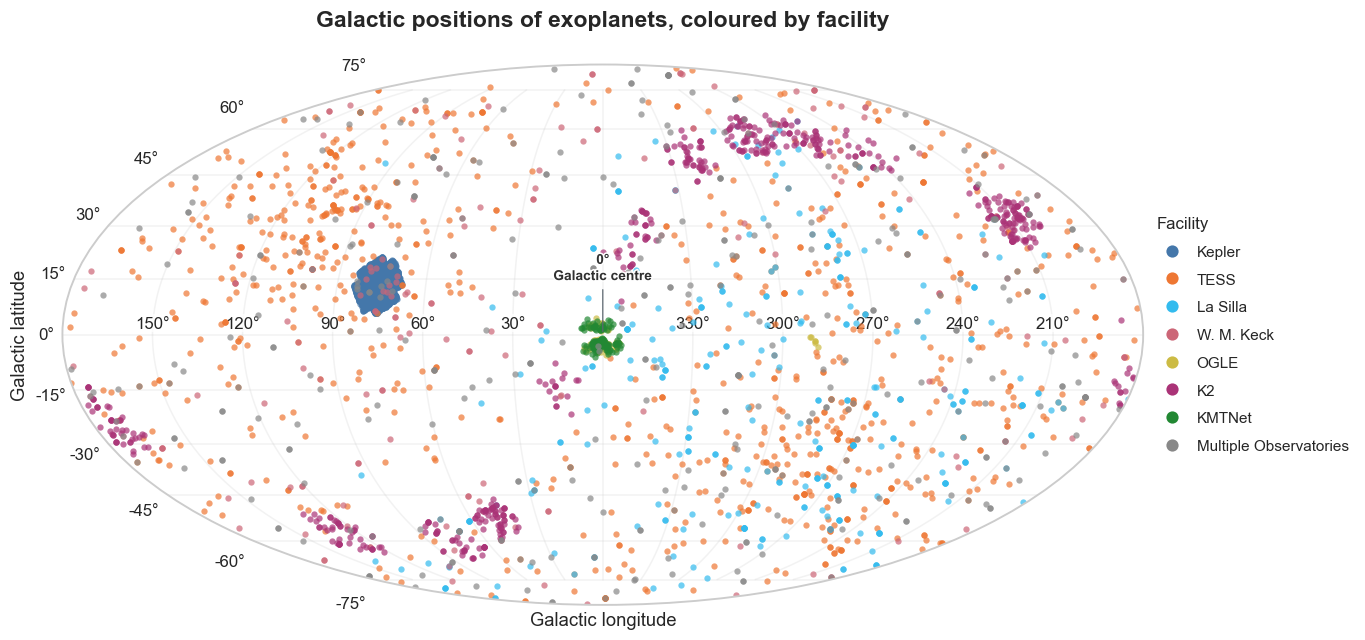

In [32]:
sky = df.loc[df["disc_facility"].isin(FACILITIES)].dropna(subset=["glon", "glat", "disc_facility"]).copy()
sky["glon_wrapped"] = ((sky["glon"] + 180) % 360) - 180
sky["longitude_rad"] = np.radians(-sky["glon_wrapped"])
sky["latitude_rad"] = np.radians(sky["glat"])

fig = plt.figure(figsize=(15, 8), dpi=DPI)
ax = fig.add_subplot(111, projection="mollweide")
for facility in FACILITIES:
    subset = sky[sky["disc_facility"] == facility]
    ax.scatter(subset["longitude_rad"], subset["latitude_rad"], s=17, alpha=0.70, color=FACILITY_COLORS[facility], linewidth=0)

tick_positions = np.arange(-150, 180, 30)
longitude_labels = ["" if int((-value) % 360) == 0 else f"{int((-value) % 360)}°" for value in tick_positions]
ax.set_xticks(np.radians(tick_positions))
ax.set_xticklabels(longitude_labels)
for label in ax.get_xticklabels():
    label.set_bbox({"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1})
    label.set_zorder(5)

ax.set_title("Galactic positions of exoplanets, coloured by facility", fontsize=15, fontweight="bold", pad=25)
ax.set_xlabel("Galactic longitude")
ax.set_ylabel("Galactic latitude")
ax.grid(alpha=0.25)
annotation = ax.annotate("0°\nGalactic centre", xy=(0, 0), xytext=(0, np.radians(14)), ha="center", va="bottom", fontsize=9, fontweight="bold", color="#303030", arrowprops={"arrowstyle": "-", "color": "#5C6770", "linewidth": 0.8}, zorder=10)
annotation.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

legend_handles = [Line2D([0], [0], marker="o", linestyle="", markersize=8, markerfacecolor=FACILITY_COLORS[facility], markeredgecolor="none", label=FACILITY_LABELS[facility]) for facility in FACILITIES]
ax.legend(handles=legend_handles, title="Facility", title_fontsize=11, fontsize=10, loc="center left", bbox_to_anchor=(1.00, 0.5), frameon=False, labelspacing=0.9, handletextpad=0.6, alignment="left")
fig.subplots_adjust(right=0.78, top=0.88, bottom=0.10)
plt.show()


## 4. Planet radius and system distance

### 4.1 Planet radius and distance by methods

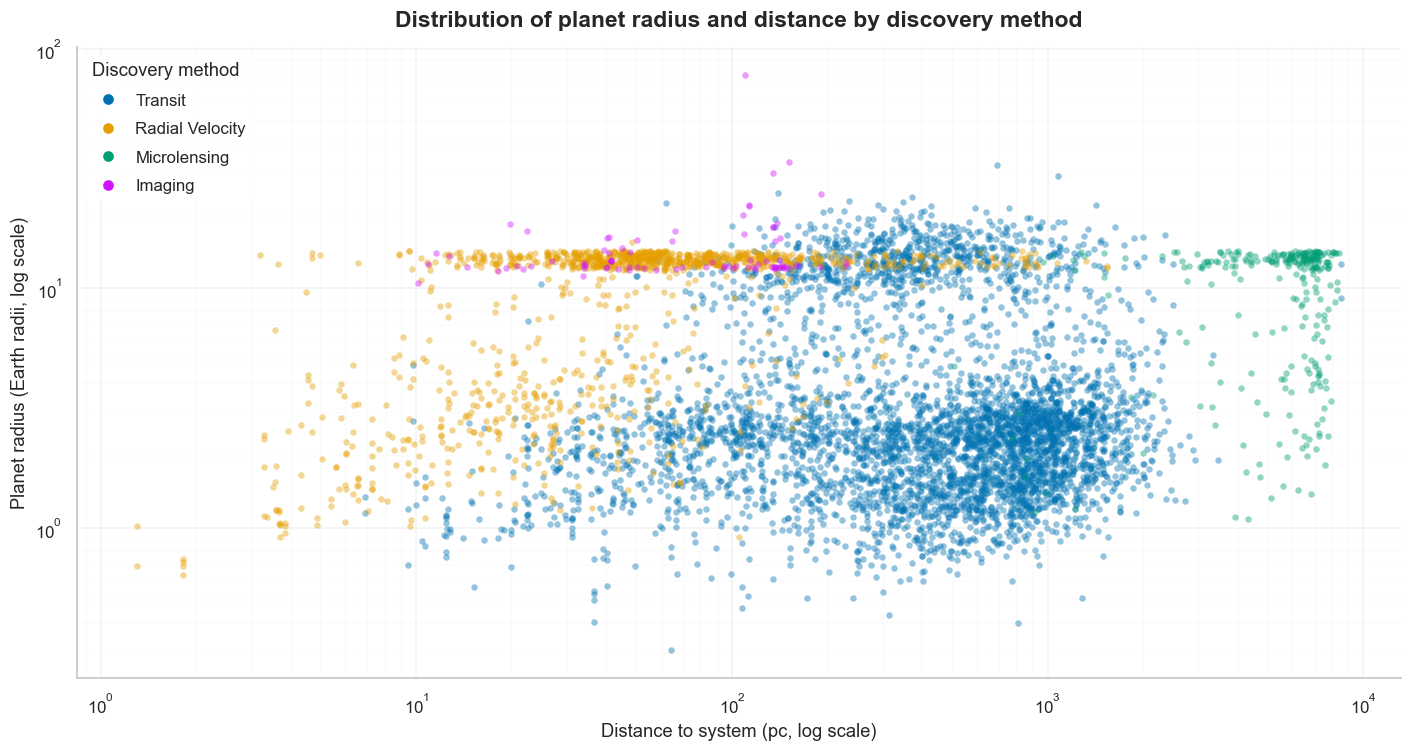

In [33]:
radius_distance = df.loc[df["pl_rade"].gt(0) & df["sy_dist"].gt(0) & df["discoverymethod"].isin(METHODS), ["pl_rade", "sy_dist", "discoverymethod"]].dropna().copy()
fig, ax = plt.subplots(figsize=(13, 7), dpi=DPI)
for method in METHODS:
    subset = radius_distance[radius_distance["discoverymethod"] == method]
    ax.scatter(subset["sy_dist"], subset["pl_rade"], s=18, alpha=0.42, linewidth=0, color=METHOD_COLORS[method])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Distribution of planet radius and distance by discovery method", **AX_TITLE_KW)
ax.set_xlabel("Distance to system (pc, log scale)")
ax.set_ylabel("Planet radius (Earth radii, log scale)")
legend_handles = [Line2D([0], [0], marker="o", linestyle="", markersize=7, markerfacecolor=METHOD_COLORS[method], markeredgecolor="none", label=method) for method in METHODS]
ax.legend(handles=legend_handles, title="Discovery method", loc="upper left", frameon=True, framealpha=0.85, facecolor="white", edgecolor="none", alignment="left", labelspacing=0.8, handletextpad=0.6)
ax.grid(which="major", alpha=0.25)
ax.grid(which="minor", alpha=0.08)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()


### 4.2 Planet radius and distance by facilities

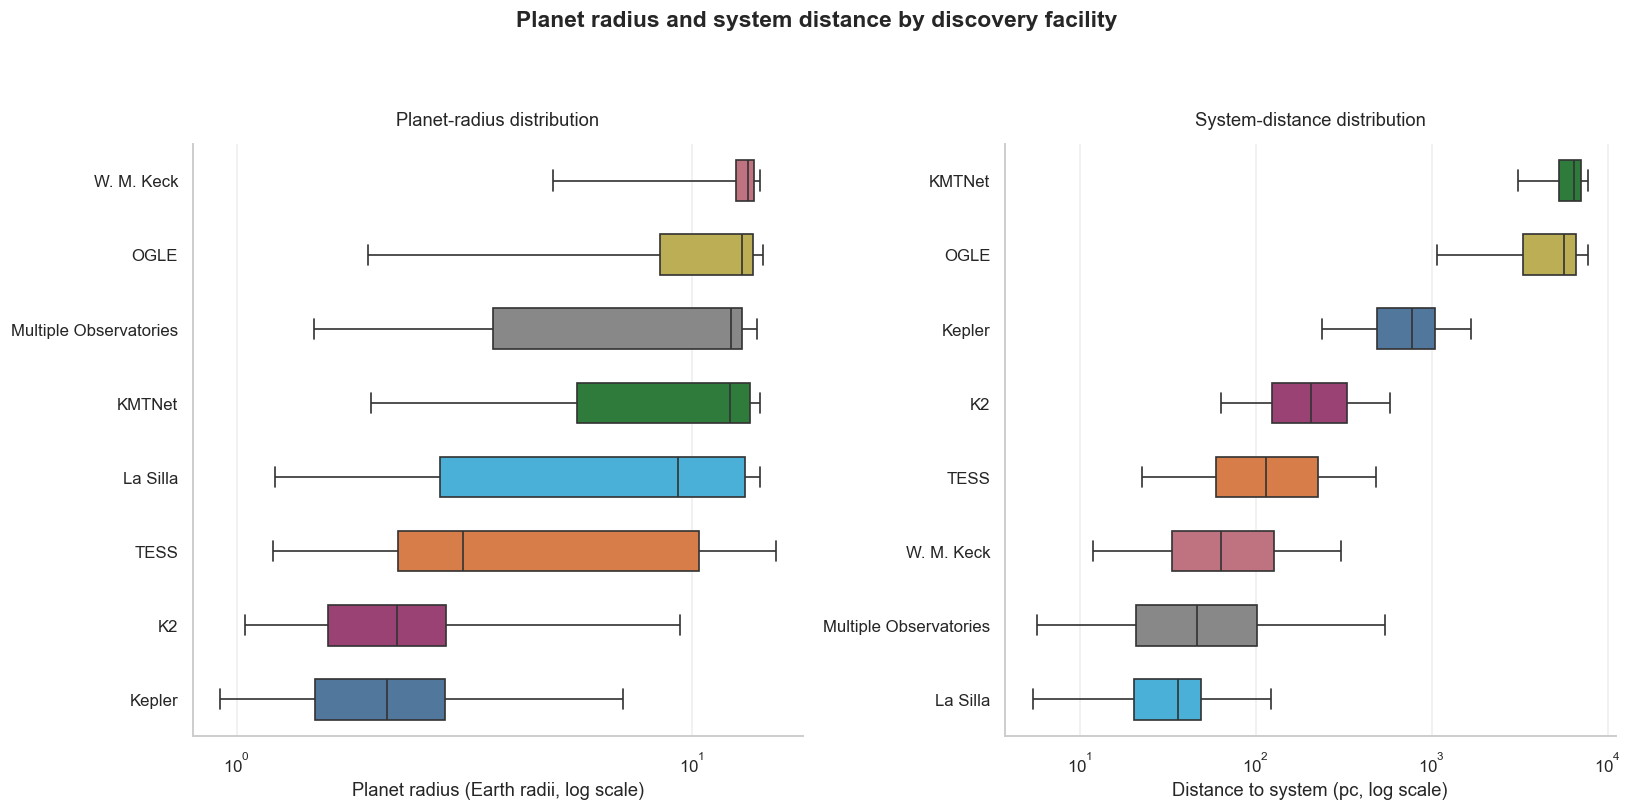

In [34]:
facility_distribution_data = df.loc[df["disc_facility"].isin(FACILITIES), ["disc_facility", "pl_rade", "sy_dist"]].copy()
facility_distribution_data["Facility"] = facility_distribution_data["disc_facility"].map(FACILITY_LABELS)
plot_settings = [
    ("pl_rade", "Planet-radius distribution", "Planet radius (Earth radii, log scale)"),
    ("sy_dist", "System-distance distribution", "Distance to system (pc, log scale)")
]

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), sharey=False, dpi=DPI)
for ax, (variable, title, xlabel) in zip(axes, plot_settings):
    plot_data = facility_distribution_data.loc[facility_distribution_data[variable].gt(0)].dropna(subset=[variable])
    facility_order = plot_data.groupby("Facility")[variable].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=plot_data, y="Facility", x=variable, order=facility_order, hue="Facility", palette=FACILITY_LABEL_COLORS, dodge=False, legend=False, showfliers=False, whis=(5, 95), width=0.55, linewidth=1.1, ax=ax)
    ax.set_xscale("log")
    ax.set_title(title, **PANEL_TITLE_KW)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.35)
    ax.grid(axis="y", visible=False)

fig.suptitle("Planet radius and system distance by discovery facility", **SUPTITLE_KW, y=0.98)
sns.despine(fig=fig)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 5. Best discovery method for the distribution of planet radii and distances 

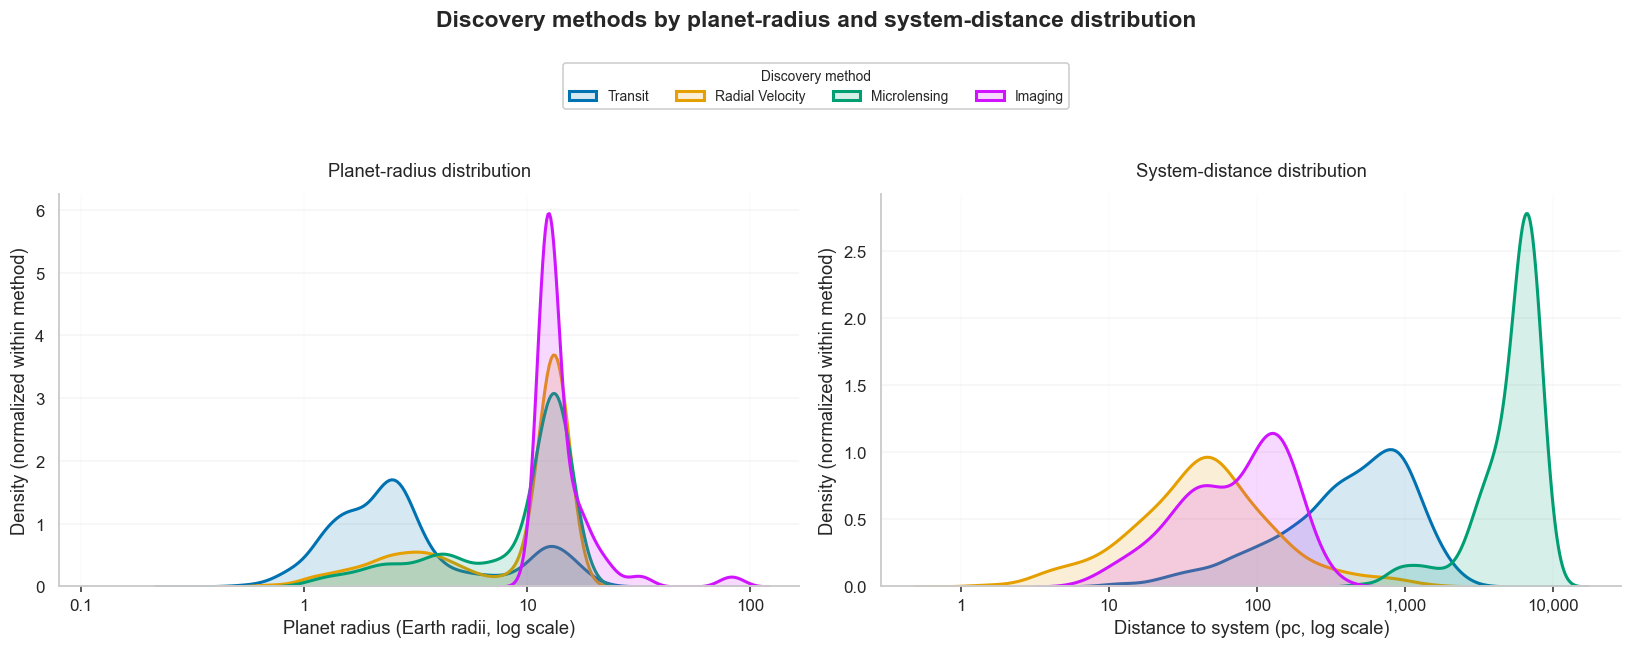

In [35]:
method_distribution_data = df.loc[df["discoverymethod"].isin(METHODS), ["discoverymethod", "pl_rade", "sy_dist"]].copy()
variables = [
    ("pl_rade", "Planet-radius distribution", "Planet radius (Earth radii, log scale)", 0.8),
    ("sy_dist", "System-distance distribution", "Distance to system (pc, log scale)", 1.2)
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=DPI)
for ax, (column, title, xlabel, bandwidth) in zip(axes, variables):
    variable_data = method_distribution_data.loc[method_distribution_data[column].gt(0), ["discoverymethod", column]].dropna().copy()
    variable_data["log_value"] = np.log10(variable_data[column])
    for method in METHODS:
        values = variable_data.loc[variable_data["discoverymethod"] == method, "log_value"]
        if len(values) >= 2:
            sns.kdeplot(x=values, ax=ax, color=METHOD_COLORS[method], fill=True, alpha=0.16, linewidth=2, bw_adjust=bandwidth, cut=3, warn_singular=False, label=method)

    curve_left, curve_right = ax.get_xlim()
    minimum = int(np.floor(variable_data["log_value"].min()))
    maximum = int(np.ceil(variable_data["log_value"].max()))
    log_ticks = np.arange(minimum, maximum + 1)
    tick_values = np.power(10.0, log_ticks)
    tick_labels = [f"{value:,.0f}" if value >= 1 else f"{value:g}" for value in tick_values]
    ax.set_xticks(log_ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(min(minimum - 0.1, curve_left), max(maximum + 0.1, curve_right))
    ax.set_ylim(bottom=0)
    ax.set_title(title, **PANEL_TITLE_KW)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density (normalized within method)")
    ax.grid(axis="y", alpha=0.20)
    ax.grid(axis="x", alpha=0.08)
    ax.tick_params(axis="x", bottom=True, top=False, direction="out", length=4, width=1)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Discovery method", loc="upper center", bbox_to_anchor=(0.5, 0.91), ncol=4, frameon=True, facecolor="white", edgecolor="#CCCCCC", framealpha=1, fontsize=9, title_fontsize=9)
fig.suptitle("Discovery methods by planet-radius and system-distance distribution", **SUPTITLE_KW, y=0.98)
sns.despine(fig=fig)
fig.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()


## 6. Planet and host-star parameters

### 6.1 Marginal distributions

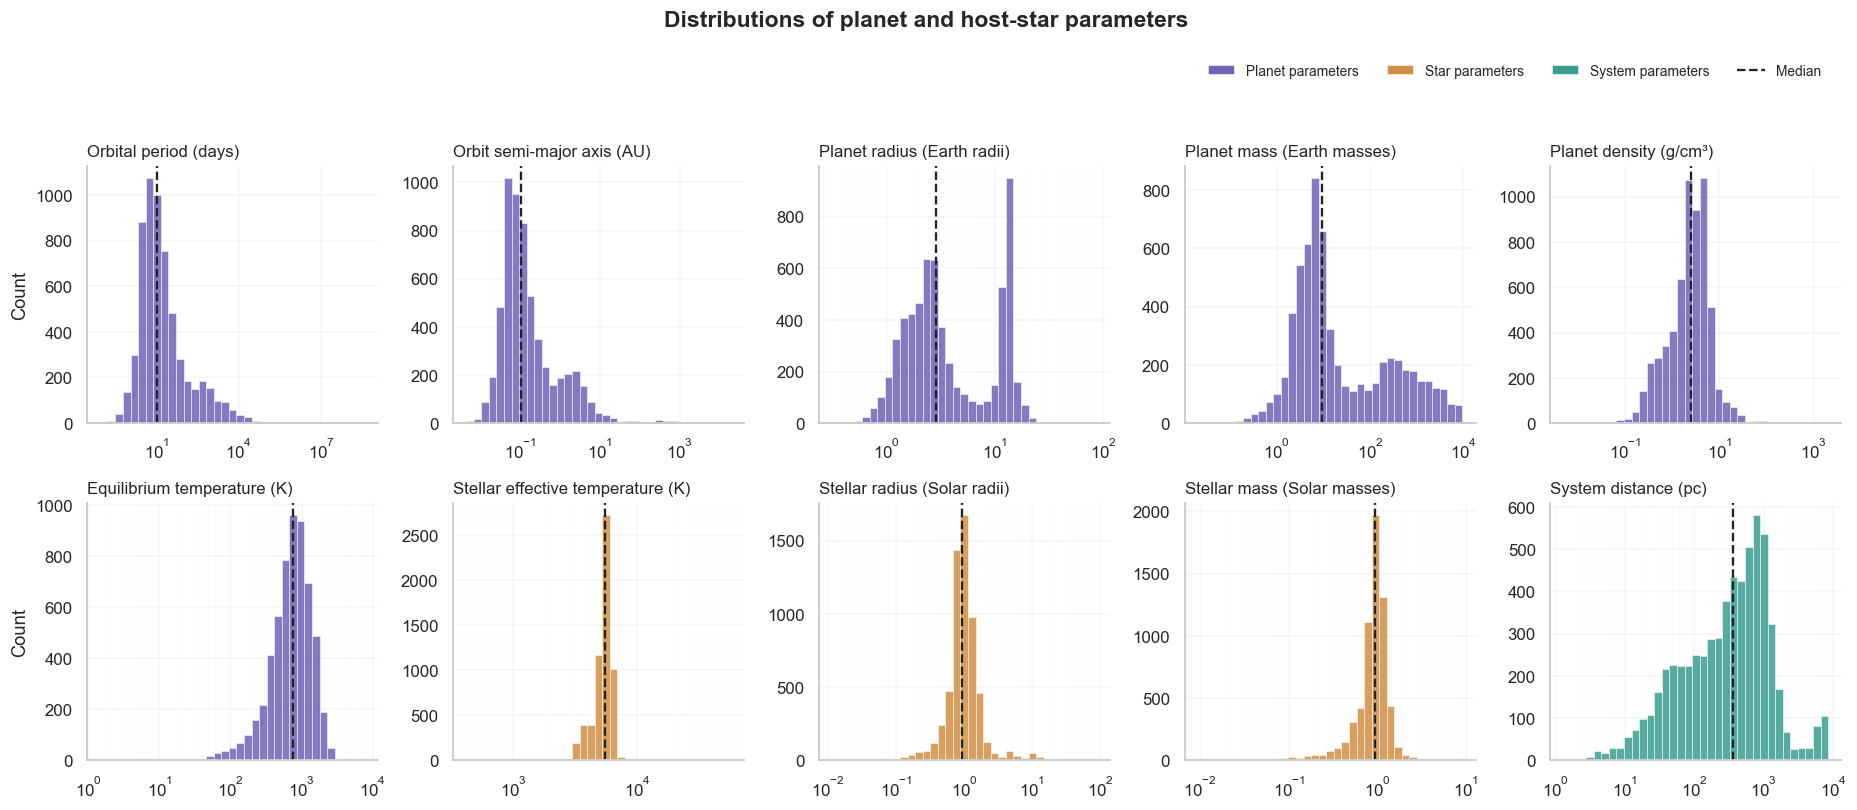

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(17, 7.5), dpi=DPI)
for i, (ax, parameter) in enumerate(zip(axes.flat, PARAMETERS)):
    values = df.loc[df[parameter].gt(0), parameter].dropna()
    bins = np.geomspace(values.min(), values.max(), 36)
    group = "Planet" if parameter.startswith("pl_") else "Star" if parameter.startswith("st_") else "System"
    ax.hist(values, bins=bins, color=GROUP_COLORS[group], alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(values.median(), color="#222222", linestyle="--", linewidth=1.5)
    ax.set_xscale("log")
    ax.set_title(PARAMETER_LABELS[parameter], loc="left", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count" if i % 5 == 0 else "")
    ax.grid(axis="x", which="major", alpha=0.18)
    ax.grid(axis="x", which="minor", alpha=0.05)
    ax.grid(axis="y", alpha=0.18)

legend_items = [
    Patch(facecolor=GROUP_COLORS["Planet"], label="Planet parameters"),
    Patch(facecolor=GROUP_COLORS["Star"], label="Star parameters"),
    Patch(facecolor=GROUP_COLORS["System"], label="System parameters"),
    Line2D([0], [0], color="#222222", linestyle="--", linewidth=1.5, label="Median")
]
fig.suptitle("Distributions of planet and host-star parameters", **SUPTITLE_KW, y=0.98)
fig.legend(handles=legend_items, loc="upper right", bbox_to_anchor=(0.985, 0.93), ncol=4, frameon=False, fontsize=9)
sns.despine(fig=fig)
fig.tight_layout(rect=[0, 0, 1, 0.89])
plt.show()


### 6.2 Selected joint distributions

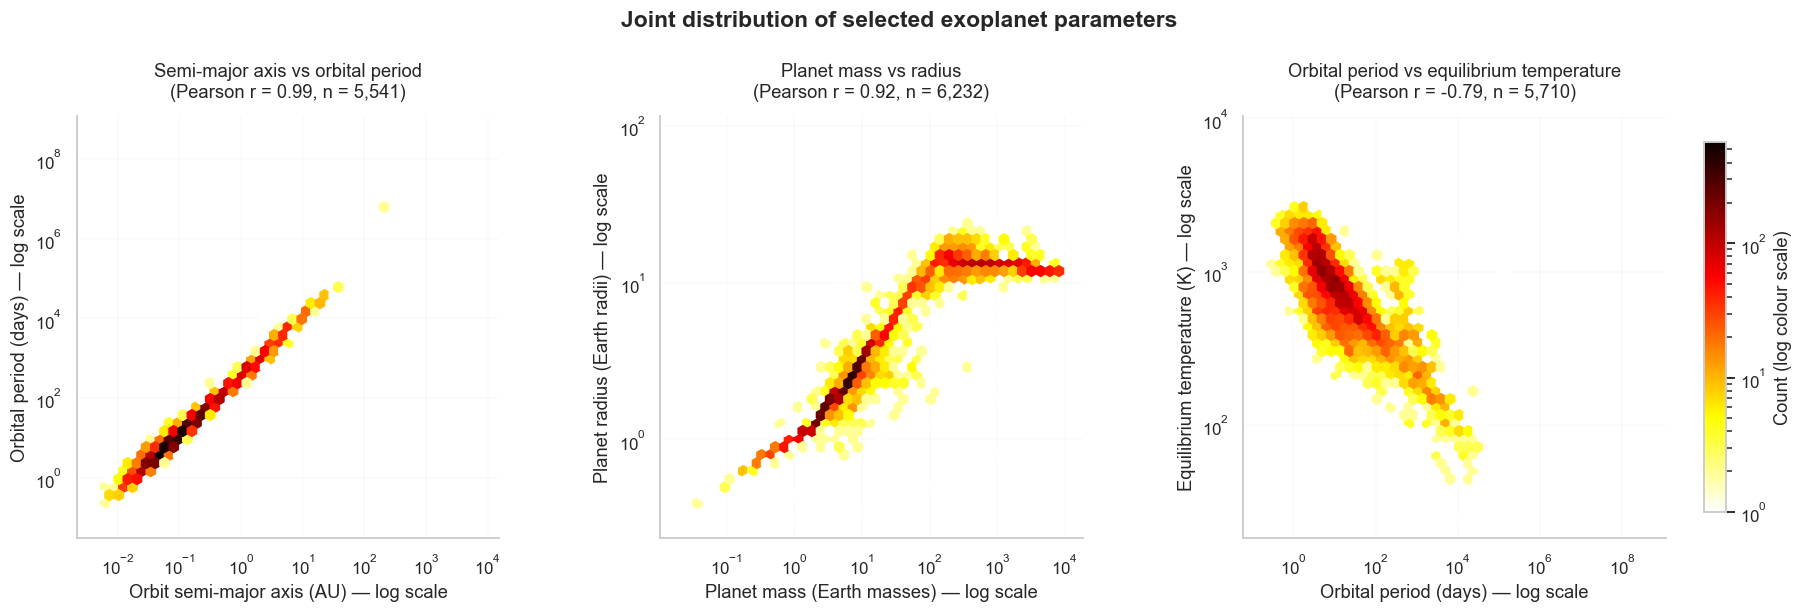

In [37]:
joint_pairs = [
    ("pl_orbsmax", "pl_orbper", "Semi-major axis vs orbital period"),
    ("pl_bmasse", "pl_rade", "Planet mass vs radius"),
    ("pl_orbper", "pl_eqt", "Orbital period vs equilibrium temperature")
]

fig, axes = plt.subplots(1, 3, figsize=(17, 6), dpi=DPI)
fig.patch.set_facecolor("white")
hexbins = []

for ax, (x, y, title) in zip(axes, joint_pairs):
    ax.set_facecolor("white")
    subset = df.loc[df[x].gt(0) & df[y].gt(0), [x, y]].dropna()
    correlation = np.corrcoef(np.log10(subset[x]), np.log10(subset[y]))[0, 1]

    hexbin = ax.hexbin(
        subset[x], subset[y],
        xscale="log", yscale="log",
        gridsize=42, mincnt=1,
        bins="log", cmap="hot_r"
    )

    hexbins.append(hexbin)
    ax.set_title(f"{title}\n(Pearson r = {correlation:.2f}, n = {len(subset):,})", **PANEL_TITLE_KW)
    ax.set_xlabel(PARAMETER_LABELS[x] + " — log scale")
    ax.set_ylabel(PARAMETER_LABELS[y] + " — log scale")
    ax.grid(alpha=0.15, color="#e0e0e0")

maximum_count = max(hexbin.get_array().max() for hexbin in hexbins)

for hexbin in hexbins:
    hexbin.set_clim(1, maximum_count)

fig.subplots_adjust(left=0.06, right=0.91, bottom=0.14, top=0.78, wspace=0.38)

colorbar_axis = fig.add_axes([0.93, 0.18, 0.012, 0.56])
colorbar = fig.colorbar(hexbins[0], cax=colorbar_axis)
colorbar.set_label("Count (log colour scale)")

fig.suptitle("Joint distribution of selected exoplanet parameters", **SUPTITLE_KW, y=0.94)

sns.despine(fig=fig)
plt.show()

### 6.3 Correlation

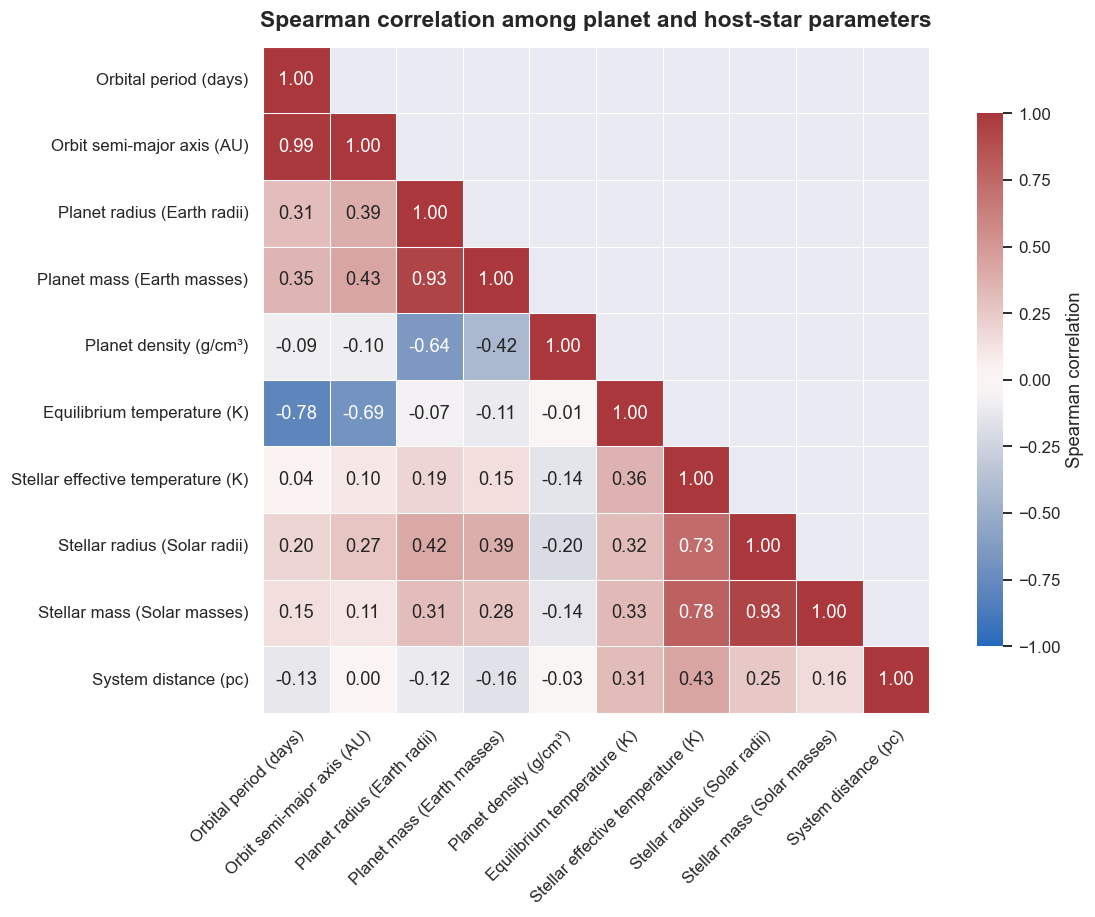

In [38]:
corr = df[PARAMETERS].corr(method="spearman")
corr.index = [PARAMETER_LABELS[name] for name in corr.index]
corr.columns = [PARAMETER_LABELS[name] for name in corr.columns]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8.5), dpi=DPI)
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, linewidths=0, cbar_kws={"label": "Spearman correlation", "shrink": 0.8}, ax=ax)
ax.set_facecolor("#EAEAF2")
ax.grid(False)
ax.set_xticks(np.arange(corr.shape[1] + 1), minor=True)
ax.set_yticks(np.arange(corr.shape[0] + 1), minor=True)
ax.set_axisbelow(False)
ax.grid(which="minor", color="white", linewidth=0.7)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_title("Spearman correlation among planet and host-star parameters", **AX_TITLE_KW)
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()
